In [3]:
!pip install roboflow ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 106.3 MB/s eta 0:00:00


In [6]:
#ignorar adevertencias

import warnings
warnings.filterwarnings('ignore')

In [7]:
from roboflow import Roboflow
import os

rf = Roboflow(api_key="dtO55yLFHUqoYO3E76u0")
project = rf.workspace("avocado-ripeness-prediction-using-images").project("avocado-ripeness-prediction")
version = project.version(3)
dataset = version.download("yolov8")

dataset_path = dataset.location
print(f"\n dataset listo en: {dataset_path} ")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Avocado-Ripeness-Prediction--3 in yolov8:: 100%|██████████| 2004/2004 [00:00<00:00, 9447.49it/s]

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

 dataset listo en: /content/Avocado-Ripeness-Prediction--3 


In [8]:
import torch

if torch.cuda.is_available():
    print(f"GPU activa: {torch.cuda.get_device_name(0)}")
else:
    print("La GPU no está activa")

GPU activa: Tesla T4


In [19]:
import yaml
import os

data_yaml_path = f"{dataset.location}/data.yaml"

with open(data_yaml_path, 'r') as f:
    data_yaml_content = yaml.safe_load(f)

# Corregir las rutas en el diccionario para usar solo el conjunto de entrenamiento
# Ya que 'valid' y 'test' no existen en el nivel superior
data_yaml_content['train'] = os.path.join('train', 'images')
data_yaml_content['val'] = os.path.join('train', 'images') # Usar train para validación
data_yaml_content['test'] = os.path.join('train', 'images') # Usar train para prueba

# Escribir el contenido corregido en el archivo data.yaml
with open(data_yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f)

print("data.yaml corregido:")
print(data_yaml_content)

data.yaml corregido:
{'names': ['Overripe', 'Ripe', 'Underripe'], 'nc': 3, 'roboflow': {'license': 'CC BY 4.0', 'project': 'avocado-ripeness-prediction', 'url': 'https://universe.roboflow.com/avocado-ripeness-prediction-using-images/avocado-ripeness-prediction/dataset/3', 'version': 3, 'workspace': 'avocado-ripeness-prediction-using-images'}, 'test': 'train/images', 'train': 'train/images', 'val': 'train/images'}


In [18]:
import os

print(f"Contenido de {dataset.location}/train:")
print(os.listdir(os.path.join(dataset.location, 'train')))

Contenido de /content/Avocado-Ripeness-Prediction--3/train:
['images', 'labels']


In [17]:
import os

print(f"Contenido de {dataset.location}:")
print(os.listdir(dataset.location))

# Comprobar si hay directorios 'valid' y 'test'
if 'valid' in os.listdir(dataset.location):
    print(f"Contenido de {dataset.location}/valid:")
    print(os.listdir(os.path.join(dataset.location, 'valid')))

if 'test' in os.listdir(dataset.location):
    print(f"Contenido de {dataset.location}/test:")
    print(os.listdir(os.path.join(dataset.location, 'test')))

Contenido de /content/Avocado-Ripeness-Prediction--3:
['data.yaml', 'train', 'README.roboflow.txt', 'README.dataset.txt']


In [21]:
from ultralytics import YOLO

print("Carganda el dataset pre-entrenado con YOLO")
model_ripeness = YOLO("yolov8n.pt")

print("Iniciando entrenamiento")
results = model_ripeness.train(
    data = f"{dataset.location}/data.yaml",
    epochs = 50,
    imgsz = 640,       # Aumentado de 224 a 640 para detectar mejor detalles en dataset grande
    batch = 16,        # Tamaño de lote
    patience = 20,     # Aumentado a 20 para evitar cierres prematuros si el progreso es lento
    save = True,
    plots = True,
    device = 'cuda' if torch.cuda.is_available() else 'cpu' # Usa GPU si está activa
)

print("El entrenamiento finalizó con éxito")

Carganda el dataset pre-entrenado con YOLO
Iniciando entrenamiento
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Avocado-Ripeness-Prediction--3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train7, nbs=64, nms=False, ops

In [22]:
from google.colab import drive
import shutil
import os

# Montar Google Drive
drive.mount('/content/drive')

# Definir las rutas
# YOLO guarda los resultados en runs/detect/train7 (o la carpeta más reciente)
# Verficar cuál es la carpeta de entrenamiento actual
path_model_yolo = "/content/runs/detect/train7/weights/best.pt"
path_drive = '/content/drive/MyDrive/6TO SEMESTRE/DESARROLLO DE SOFTWARE II/model_avocado_ripeness-v1'

# Crear la carpeta en Drive si no existe
os.makedirs(path_drive, exist_ok=True)

name_model = "avocado_ripeness.pt"
path_ripiness = os.path.join(path_drive, name_model)

if os.path.exists(path_model_yolo):
    shutil.copy(path_model_yolo, path_ripiness)
    print(f"Modelo YOLO guardado exitosamente en: {path_ripiness}")
else:
    print(f"No se encontró el archivo en {path_model_yolo}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modelo YOLO guardado exitosamente en: /content/drive/MyDrive/6TO SEMESTRE/DESARROLLO DE SOFTWARE II/model_avocado_ripeness-v1/avocado_ripeness.pt


Realizando predicciones en 6 imágenes aleatorias...

0: 640x640 1 Ripe, 5.1ms
1: 640x640 1 Underripe, 5.1ms
2: 640x640 1 Underripe, 5.1ms
3: 640x640 1 Underripe, 5.1ms
4: 640x640 1 Underripe, 5.1ms
5: 640x640 1 Ripe, 5.1ms
Speed: 2.8ms preprocess, 5.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict9


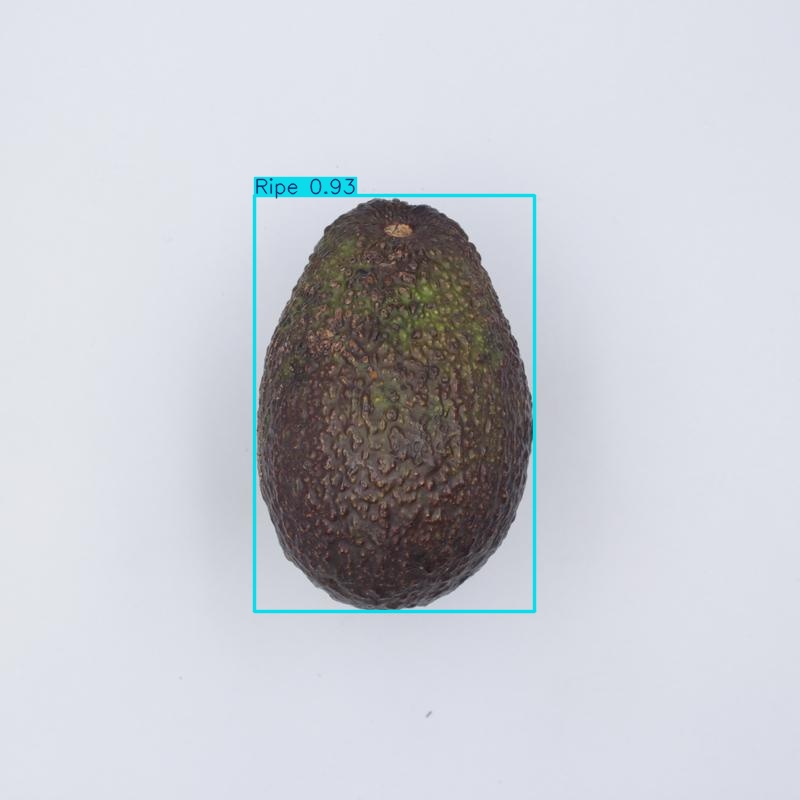

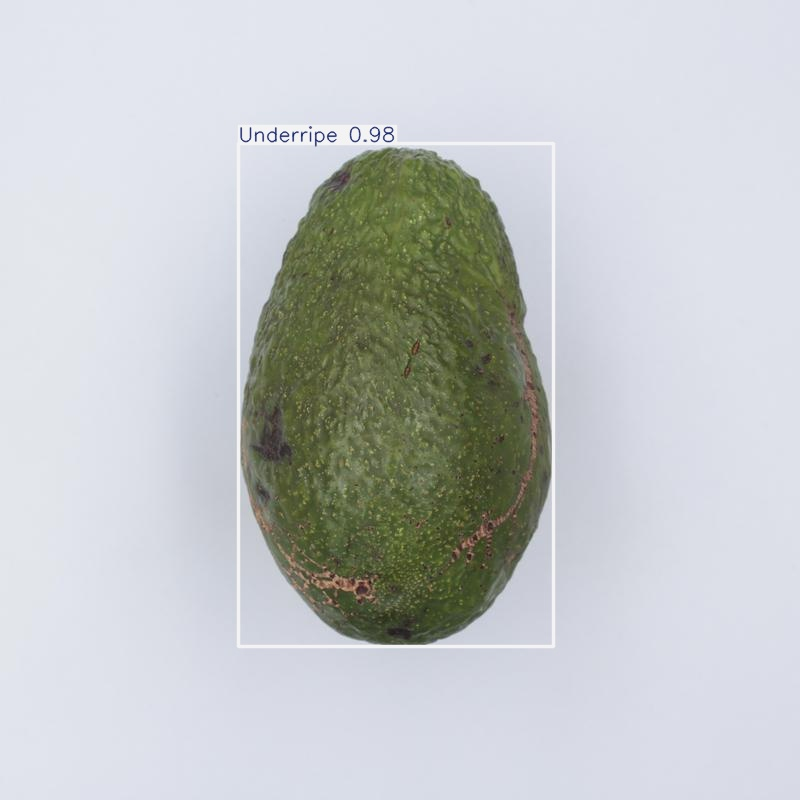

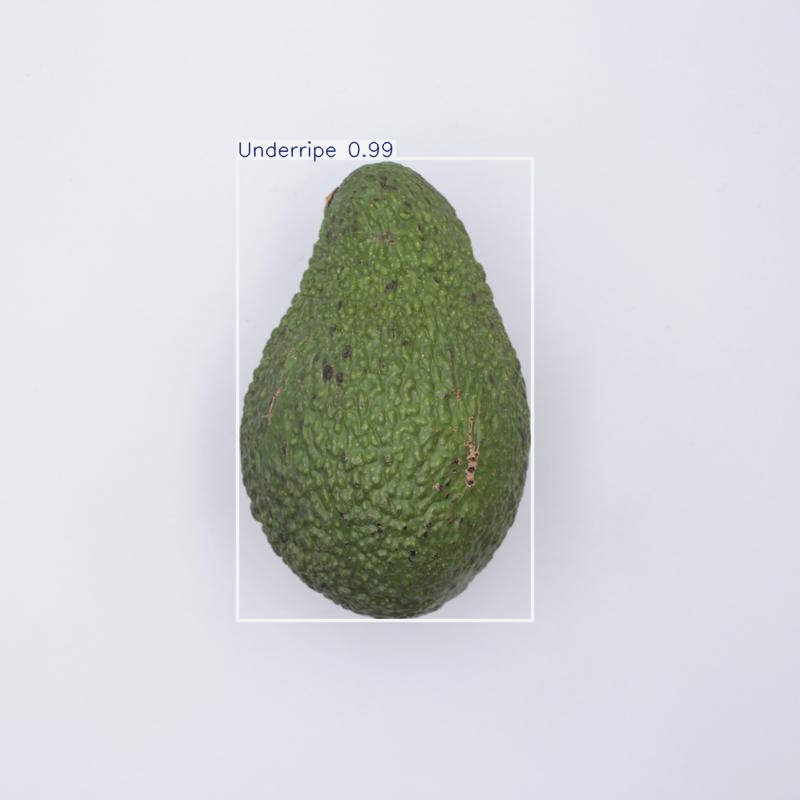

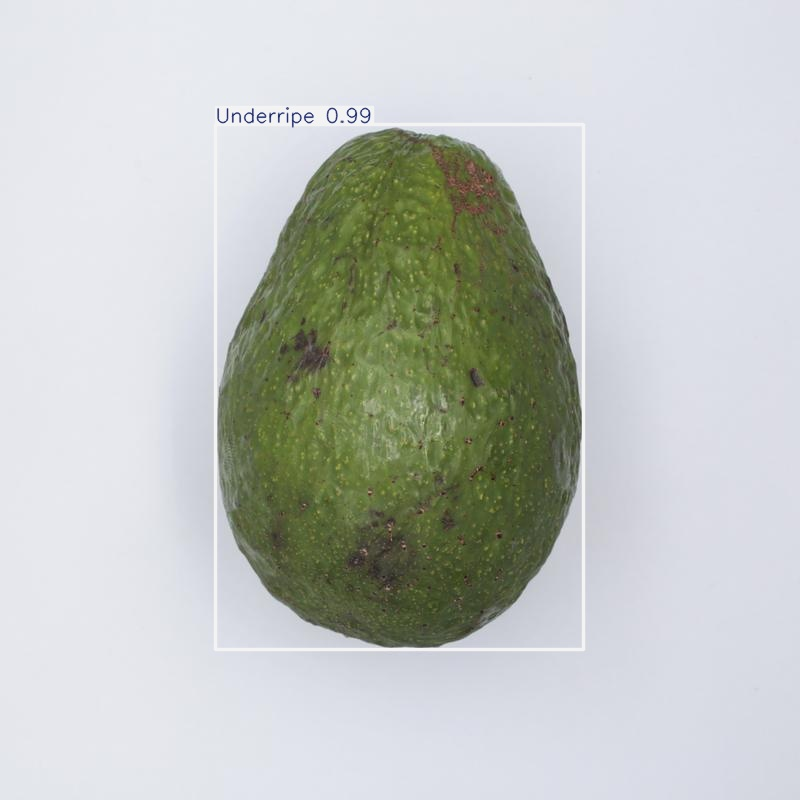

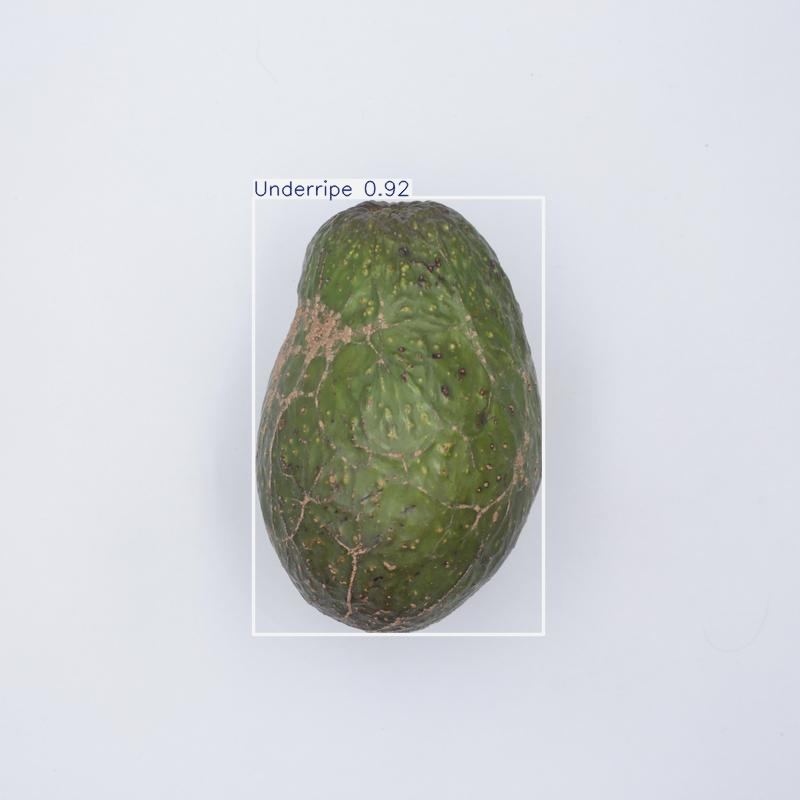

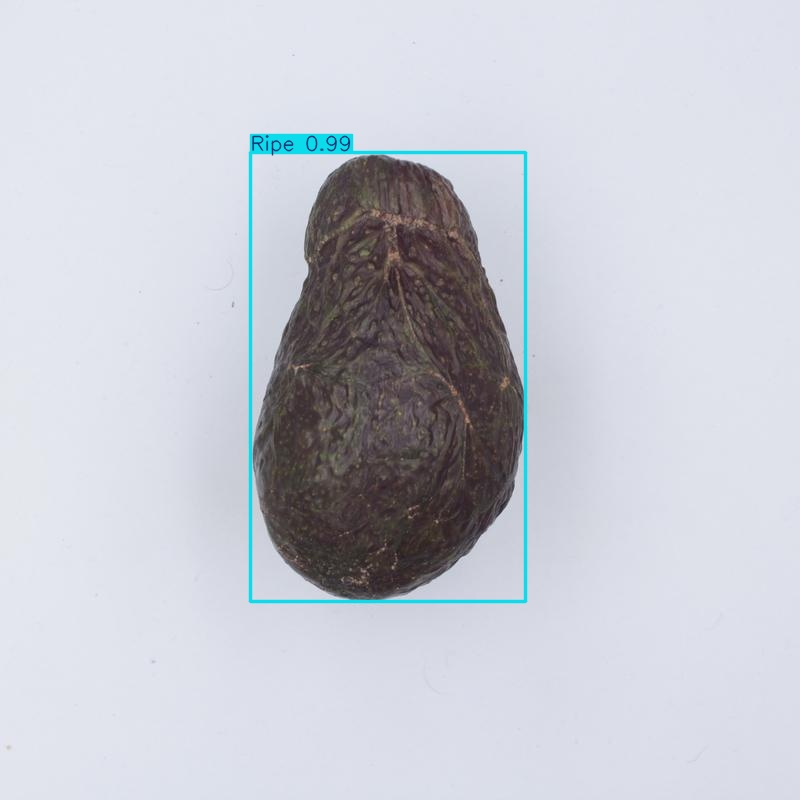

In [31]:
from ultralytics import YOLO
import os
import glob
import random
from IPython.display import Image, display

# Cargar el modelo con los mejores pesos obtenidos
model_path = '/content/runs/detect/train7/weights/best.pt'
model = YOLO(model_path)

# Obtener todas las imágenes disponibles
all_images = glob.glob(f"{dataset.location}/train/images/*.jpg")

# Seleccionar 6 imágenes al azar
test_images = random.sample(all_images, min(len(all_images), 6))

print(f"Realizando predicciones en {len(test_images)} imágenes aleatorias...")

# Ejecutar la predicción
results = model.predict(source=test_images, save=True, conf=0.25)

# Mostrar las imágenes resultantes
for result in results:
    res_path = os.path.join(result.save_dir, os.path.basename(result.path))
    if os.path.exists(res_path):
        display(Image(filename=res_path, width=600))
    else:
        print(f"Buscando resultado en: {result.save_dir}")

Matriz de Confusión:


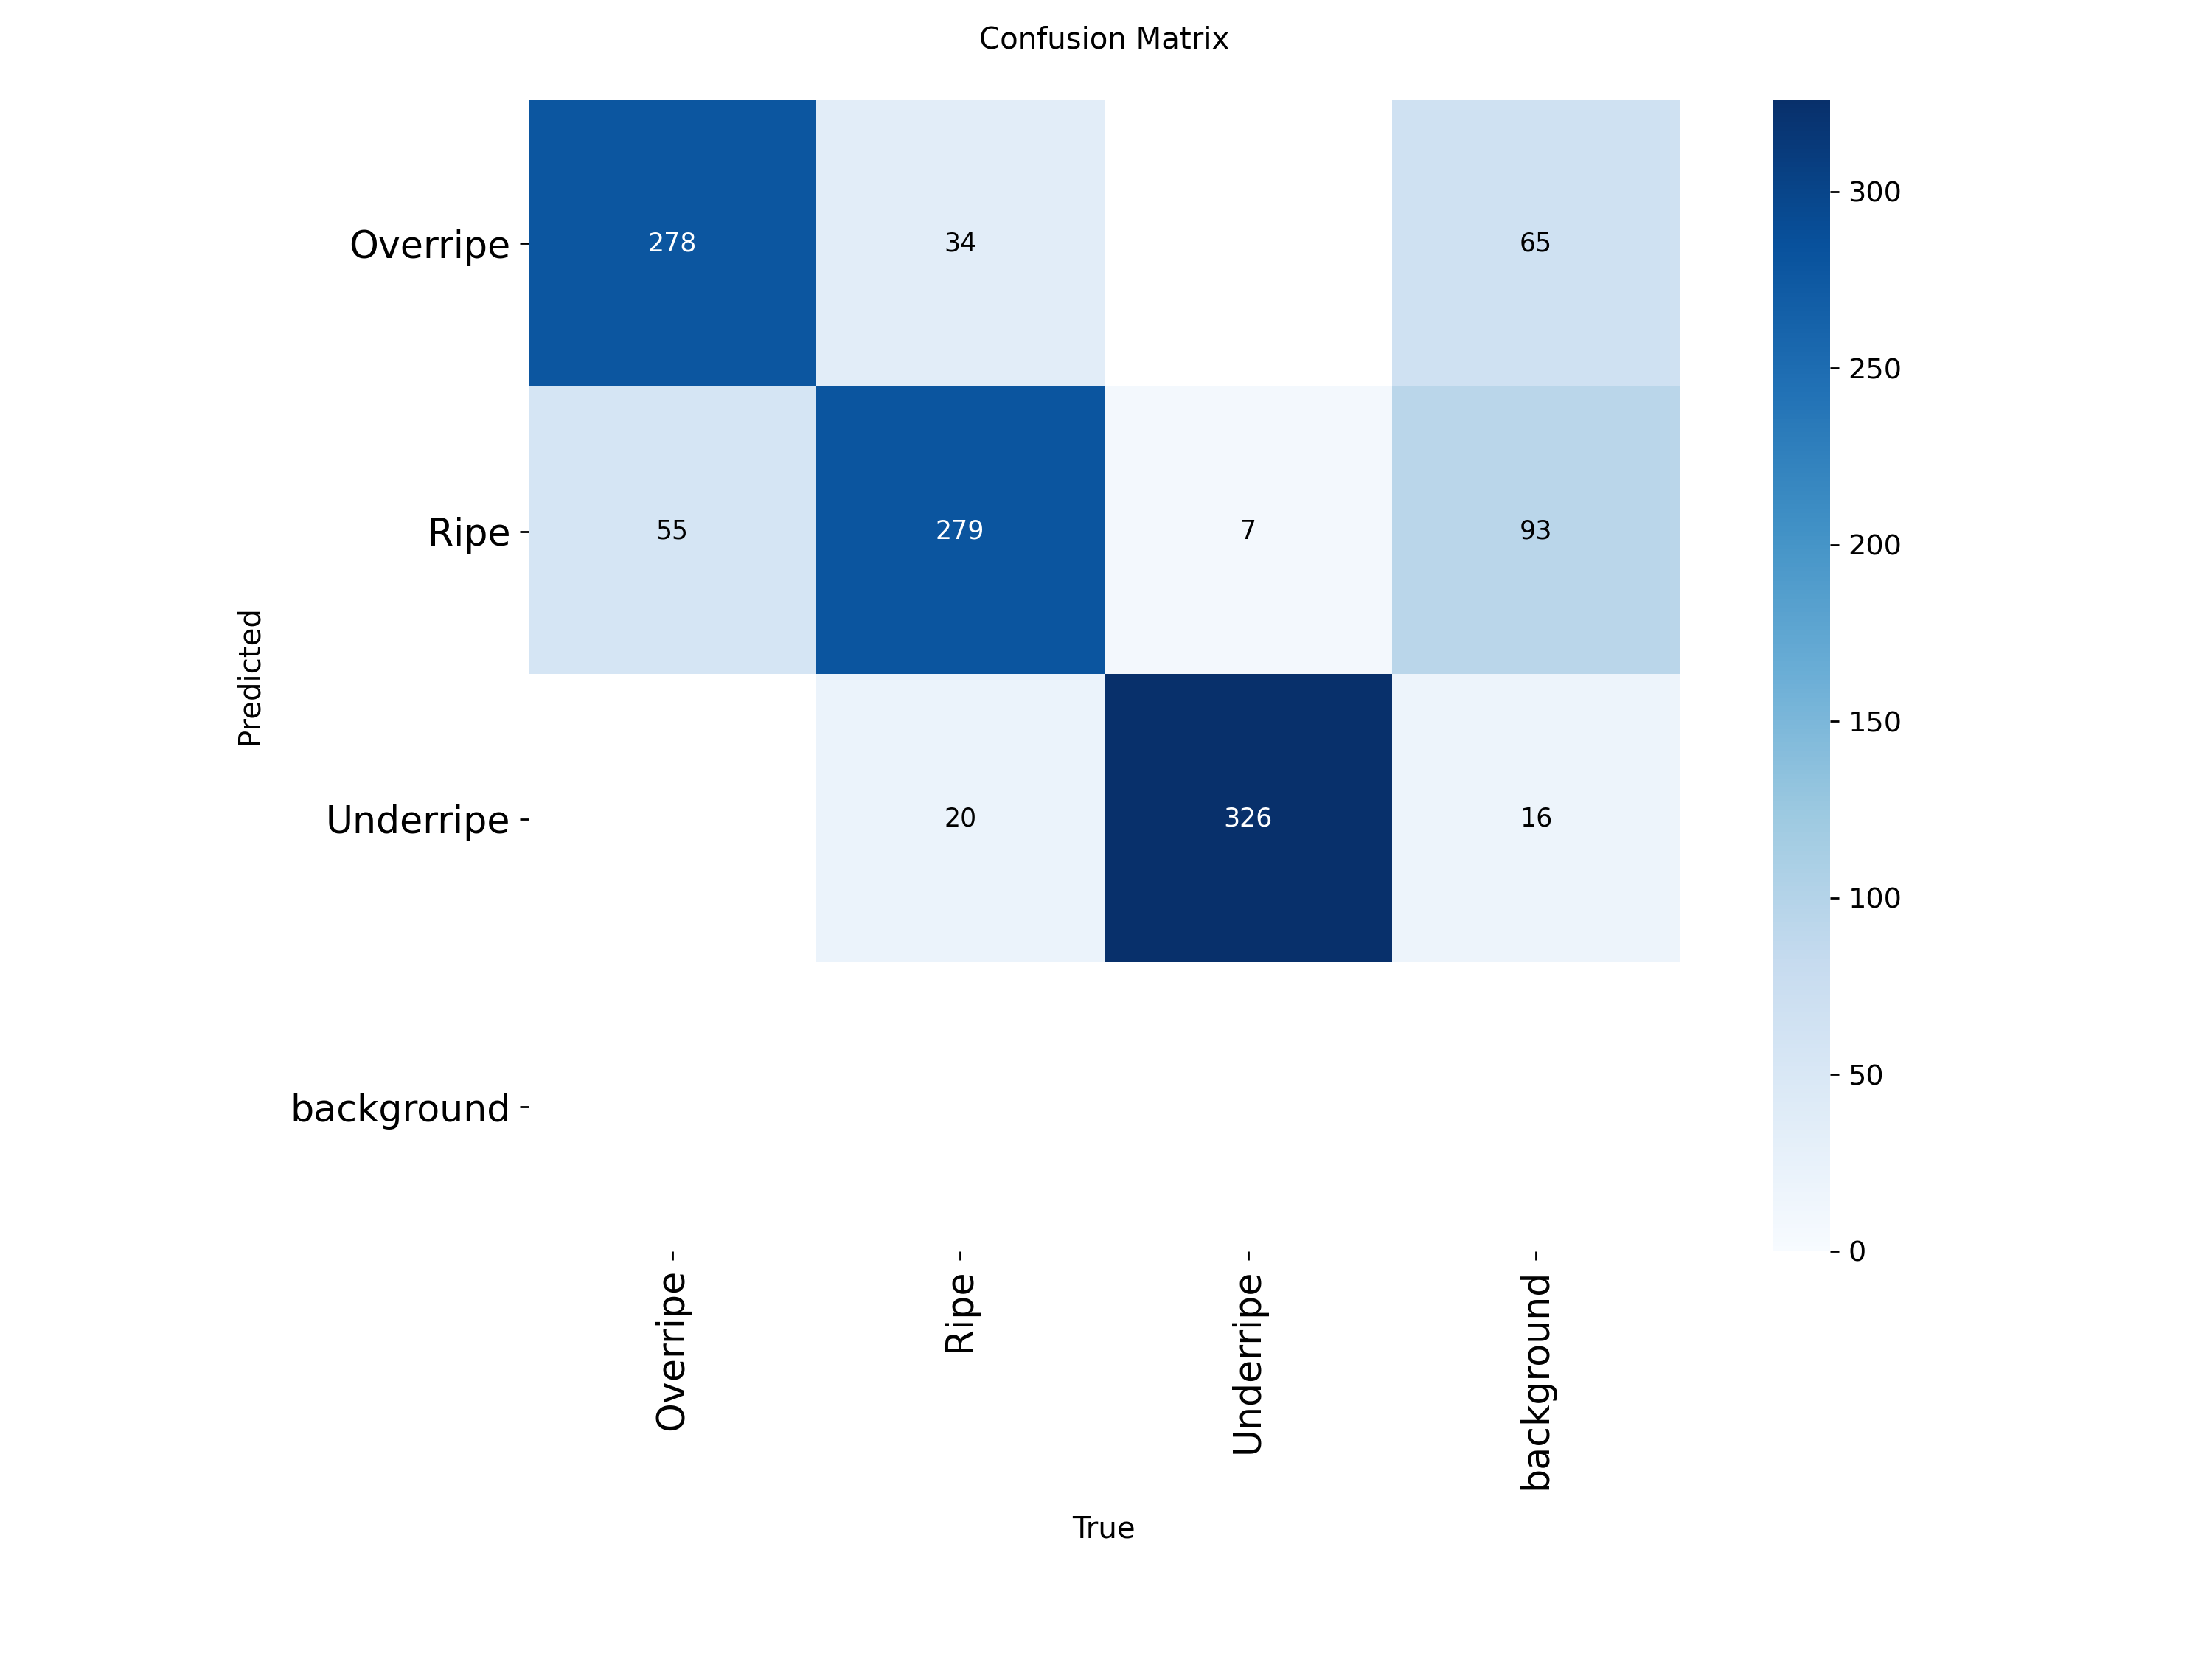

In [33]:
from IPython.display import Image, display
import os

# La ruta donde se guardaron los resultados de la carpeta train7
cm_path = '/content/runs/detect/train7/confusion_matrix.png'

if os.path.exists(cm_path):
    print("Matriz de Confusión:")
    display(Image(filename=cm_path))
else:
    print(f"No se encontró la matriz en {cm_path}.")